# ***Regiones admisibles de los procesos AR(1) y AR(2)***

## **Considere un proceso AR(1):**

$$
(1 - \phi B) W_t = \alpha_t
$$

---

Se recuerda que si $|\phi| < 1$, este proceso es **estacionario**.

A partir de esta condición, se identifican dos **regiones admisibles**.

---

**Región admisible 1:**

$$
0 < \phi < 1
$$


In [1]:
import plotly.io as pio
pio.renderers.default = "png"

In [2]:
import re
from pathlib import Path
import plotly.io as pio

# ====== CONFIG (EDIT ONCE) ======
GITHUB_USERNAME = "nuriaarroyo"      # <-- your username
GITHUB_REPO = "ecoII"                # <-- your repo name
PAGES_ROOT = "docs"                  # <-- GitHub Pages folder
# =================================

def _slugify(text: str) -> str:
    text = text.strip()
    text = re.sub(r"[^\w\d\-]+", "_", text, flags=re.UNICODE)
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "plotly_figure"

def find_repo_root(start: Path = None) -> Path:
    start = start or Path.cwd()
    for p in [start, *start.parents]:
        if (p / ".git").exists() or (p / "README.md").exists():
            return p
    return start

def save_plotly_html_from_title(
    fig,
    site_subfolder="interactive",
    auto_open=False,
    print_link=True
):
    """
    Saves a Plotly figure as HTML in the GitHub Pages folder
    and prints the FINAL public URL.
    """

    # 1. title → filename
    title = getattr(fig.layout.title, "text", None) or "plotly_figure"
    filename = _slugify(title) + ".html"

    # 2. repo root
    repo_root = find_repo_root(Path.cwd())

    # 3. output directory (doca/interactive)
    out_dir = repo_root / PAGES_ROOT / site_subfolder
    out_dir.mkdir(parents=True, exist_ok=True)

    # 4. save path
    out_path = out_dir / filename

    # 5. write HTML
    pio.write_html(
        fig,
        file=str(out_path),
        full_html=True,
        include_plotlyjs="cdn",
        auto_open=auto_open
    )

    # 6. build public URL
    public_url = (
        f"https://{GITHUB_USERNAME}.github.io/"
        f"{GITHUB_REPO}/{site_subfolder}/{filename}"
    )

    if print_link:
        print("✅ Interactive Plotly URL:")
        print(public_url)

    return out_path, public_url


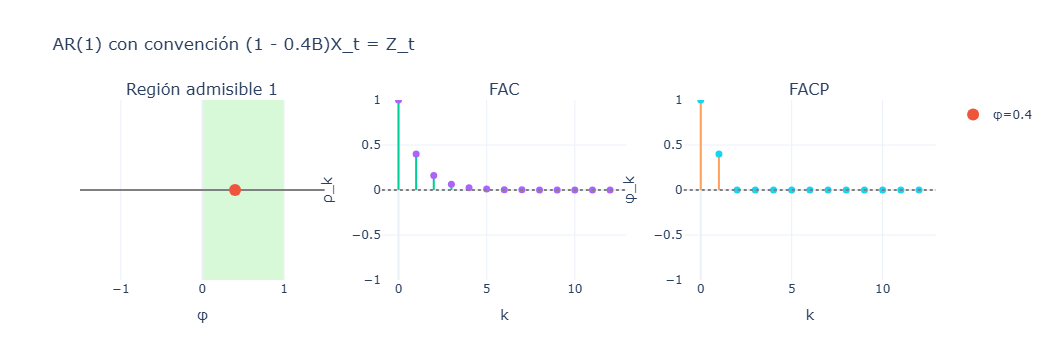

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_1_con_convención_1_-_0_4B_X_t_Z_t.html


In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- util: stem (líneas verticales) ---
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name=name, showlegend=False)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7), name=f"{name} (•)", showlegend=False)
    return lines, dots

# --- ACF/PACF teóricas AR(1) con (1 - φB)X_t = Z_t ---
def acf_ar1(phi, m):
    lags = np.arange(m+1)
    rho = phi**lags
    return lags, rho

def pacf_ar1(phi, m):
    lags = np.arange(m+1)
    pacf = np.zeros(m+1); pacf[0] = 1.0; pacf[1] = phi
    return lags, pacf

def panel_ar1_region_fac_pacf(phi=0.4, m=12, xlim=1.5):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región admisible 1", "FAC", "FACP"),
        column_widths=[0.33, 0.33, 0.34]
    )

    # --- 1) Región admisible en la recta real ---

    fig.add_shape(
            type="rect",
            x0=0, x1=1, y0=0, y1=1,
            xref="x1", yref="paper",     # usa el eje x del 1er subplot y la altura del panel
            fillcolor="lightgreen",
            opacity=0.35,
            line_width=0,
            layer="below"
        )
    
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0,0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=[phi], y=[0], mode="markers",
                             marker=dict(size=12), name=f"φ={phi}"),
                  row=1, col=1)
    fig.update_xaxes(range=[-xlim, xlim], title_text="φ", row=1, col=1)
    fig.update_yaxes(visible=False, row=1, col=1)

    # --- 2) FAC ---
    lags, rho = acf_ar1(phi, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)

    # --- 3) FACP ---
    lags_p, pacf = pacf_ar1(phi, m)
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3); fig.add_trace(dots, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)

    fig.update_layout(template="plotly_white", width=1050, height=360,
                      title=f"AR(1) con convención (1 - {phi}B)X_t = Z_t")
    return fig

# ================== USO ==================
# tu ejemplo: φ = 0.4
fig = panel_ar1_region_fac_pacf(phi=0.4, m=12, xlim=1.5)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)


**Modelo:**
- $W_t = \phi W_{t-1} + \alpha_t$

**FAC (Función de autocorrelación):**
- $\rho_k = \phi^k$

**FACP (Función de autocorrelación parcial):**
- $\phi$ en el primer rezago, luego cero.

_(La FAC decae exponencialmente a medida que $k$ crece, si $0 < \phi < 1$)_

 *Ejemplo visto en clase 2*

---



**Región admisible 2:**

$$
-1 < \phi < 0
$$


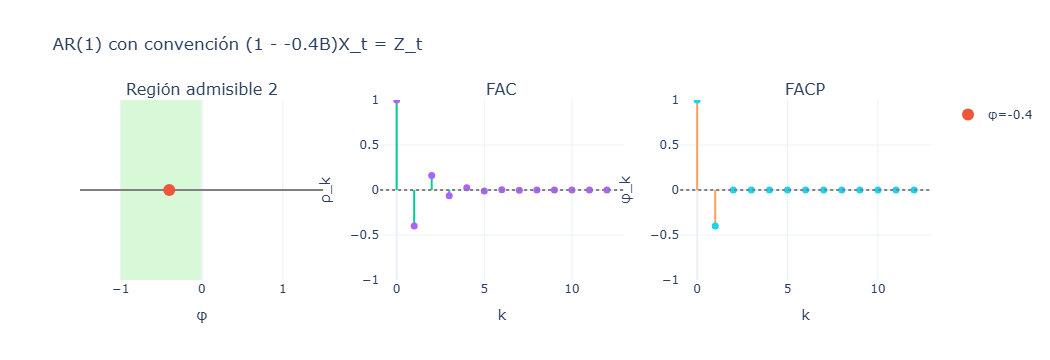

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_1_con_convención_1_-_-0_4B_X_t_Z_t.html


In [4]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- util: stem (líneas verticales) ---
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name=name, showlegend=False)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7), name=f"{name} (•)", showlegend=False)
    return lines, dots

# --- ACF/PACF teóricas AR(1) con (1 - φB)X_t = Z_t ---
def acf_ar1(phi, m):
    lags = np.arange(m+1)
    rho = phi**lags
    return lags, rho

def pacf_ar1(phi, m):
    lags = np.arange(m+1)
    pacf = np.zeros(m+1); pacf[0] = 1.0; pacf[1] = phi
    return lags, pacf

def panel_ar1_region_fac_pacf(phi=0.4, m=12, xlim=1.5):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región admisible 2", "FAC", "FACP"),
        column_widths=[0.33, 0.33, 0.34]
    )

    # --- 1) Región admisible en la recta real ---

    fig.add_shape(
            type="rect",
            x0=-1, x1=0, y0=0, y1=1,
            xref="x1", yref="paper",     # usa el eje x del 1er subplot y la altura del panel
            fillcolor="lightgreen",
            opacity=0.35,
            line_width=0,
            layer="below"
        )
    
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0,0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=[phi], y=[0], mode="markers",
                             marker=dict(size=12), name=f"φ={phi}"),
                  row=1, col=1)
    fig.update_xaxes(range=[-xlim, xlim], title_text="φ", row=1, col=1)
    fig.update_yaxes(visible=False, row=1, col=1)

    # --- 2) FAC ---
    lags, rho = acf_ar1(phi, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)

    # --- 3) FACP ---
    lags_p, pacf = pacf_ar1(phi, m)
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3); fig.add_trace(dots, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)

    fig.update_layout(template="plotly_white", width=1050, height=360,
                      title=f"AR(1) con convención (1 - {phi}B)X_t = Z_t")
    return fig

# ================== USO ==================
# tu ejemplo: φ = -0.4
fig = panel_ar1_region_fac_pacf(phi=-0.4, m=12, xlim=1.5)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)



**Modelo:**
$$
(1 - \phi B) W_t = \alpha_t
$$

**Comportamiento de la FAC:**

- La función de autocorrelación (FAC) está dada por:
  
  $$
  \rho_k = \phi^k
  $$

- En esta región, la FAC tiende a cero **con signos alternados** si $-1 < \phi < 0$.



**Notar en Gráficos:**

- **FAC**: Decaimiento oscilatorio alrededor de cero.
- **FACP**: Primer rezago distinto de cero; los demás, cero.

---



**Ejemplo:**

Proceso:

$$
(1 + 0.4B) X_t = Z_t
$$

Entonces:

- $\rho_1 = (-0.4)^1 = -0.4$
- $\rho_2 = (-0.4)^2 = 0.16$
- $\rho_3 = (-0.4)^3 = -0.064$
- $\dots$


---

## **Consideremos un proceso AR(2):**

$$
(1 - \phi_1 B - \phi_2 B^2) W_t = \alpha_t \quad ; \quad \{\alpha_t\} \sim \text{wn}(0, \sigma_\alpha^2)
$$

---

Sabemos que este proceso es **estacionario** si se cumplen las siguientes **tres condiciones**:

1. $|\phi_2| < 1$

2. $\phi_2 - \phi_1 < 1$

3. $\phi_2 + \phi_1 < 1$

---


A partir de estas condiciones se tienen las siguientes:


### **Regiones admisibles para el proceso AR(2)**

---

**Región admisible 1 para el proceso AR(2)**

**Modelo:**
$$
(1 - \phi_1 B - \phi_2 B^2) W_t = \alpha_t
$$


**Condiciones de la región:**

- $\phi_1 < 0$
- $\phi_1^2 + 4\phi_2 \geq 0$
- $\phi_2 + \phi_1 < 1$


**Interpretación gráfica:**

- Esta región se encuentra en el triángulo donde:
  - $\phi_2 = -\phi_1$
  - $\phi_1^2 + 4\phi_2 = 1$
  - Las autocorrelaciones (FAC) decaen exponencialmente
  - Las primeras $\rho_k$ son positivas y luego se alternan de signo




In [5]:
import numpy as np
import plotly.graph_objects as go

def ar2_region_quad(phi1_point=0.4, phi2_point=0.2):
    x = np.linspace(-2, 2, 600)
    

    # fronteras del triángulo (estacionariedad)
    tri_x = [-2, 2, 0, -2]
    tri_y = [ -1, -1,1,  -1]

    # curvas de referencia
    disc = -0.25 * x**2          # parábola Δ=0
    y0   = np.zeros_like(x)      # φ2 = 0

    fig = go.Figure()

    
    
    # triángulo
    fig.add_trace(go.Scatter(x=tri_x, y=tri_y, mode="lines",
                             line=dict(color="black", width=1), # Borde negro
                             fill="toself", fillcolor="rgba(144, 238, 144, 0.4)", # Verde claro con transparencia
                             name="Región de Estacionariedad"))

    # parábola (discriminante)
    fig.add_trace(go.Scatter(x=x, y=disc, mode="lines",
                             line=dict(color="black", width=2, dash="dot"),
                             name="Δ=0  (φ₂ = −¼ φ₁²)"))




    # marcas en los vértices
    fig.add_trace(go.Scatter(x=[-2, 2, 0], y=[1, 1, -1], mode="markers+text",
                             marker=dict(size=6, color="black"),
                             text=["(-2,1)", "(2,1)", "(0,-1)"],
                             textposition="top center",
                             showlegend=False))

    # tu punto
    fig.add_trace(go.Scatter(x=[phi1_point], y=[phi2_point], mode="markers+text",
                             marker=dict(size=12, color="red", symbol="circle"),
                             text=[f"({phi1_point:.2f}, {phi2_point:.2f})"],
                             textposition="bottom center",
                             name="punto (φ₁, φ₂)"))

    # etiquetas rápidas de sub-regiones (opcional)
    fig.add_annotation(x=-1.0, y=0.3, text="Real\n(φ₁<0)", showarrow=False)
    fig.add_annotation(x= 1.0, y=0.3, text="Real\n(φ₁>0)", showarrow=False)
    fig.add_annotation(x=-1.0, y=-0.6, text="Compleja\n(φ₁<0)", showarrow=False)
    fig.add_annotation(x= 1.0, y=-0.6, text="Compleja\n(φ₁>0)", showarrow=False)

    if phi1_point < 0:
        if (phi1_point**2 + 4*phi2_point)<0:
            region = 3
        else:
            region = 1
    else:
        if (phi1_point**2 + 4*phi2_point)<0:
            region = 4
        else:
            region =2

    fig.update_layout(
        template="simple_white",
        width=700, height=520,
        title=f"AR(2)<br> Triángulo de estacionariedad + parábola del discriminante<br>Punto en Región {region}",
        xaxis=dict(title="φ₁", range=[-2.2, 2.2], zeroline=True),
        yaxis=dict(title="φ₂", range=[-1.3, 1.3], zeroline=False),
        showlegend=False
    )
    return fig



In [6]:
import numpy as np
import plotly.graph_objects as go

# ---------- ACF teórica AR(p) con convención X_t - sum(phi_j X_{t-j}) = Z_t ----------
def acf_ar_negative(phi, m=24, M=1000):
    """
    phi: iterable (phi1,...,phi_p) con TU convención (el modelo lleva '−' delante).
    m  : rezago máximo a devolver (inclusive).
    M  : truncación para los pesos MA(∞) (entre 500-2000 suele bastar si el AR es estable).
    return: lags (0..m), rho
    """
    phi = np.asarray(phi, dtype=float)
    p = len(phi)

    # psi-weights del AR como MA(∞)
    psi = np.zeros(M+1)
    psi[0] = 1.0
    for k in range(1, M+1):
        # psi_k = sum_{j=1}^p phi_j * psi_{k-j}
        acc = 0.0
        for j in range(1, p+1):
            if k-j >= 0:
                acc += phi[j-1] * psi[k-j]
        psi[k] = acc

    # autocovarianzas (sigma^2 factor se cancela al normalizar)
    gamma = np.zeros(m+1)
    for k in range(m+1):
        # sum_{i=0}^{M-k} psi_i * psi_{i+k}
        gamma[k] = np.dot(psi[:M-k+1], psi[k:M+1])

    rho = gamma / gamma[0]
    lags = np.arange(m+1)
    return lags, rho

# ---------- Stem-plot en Plotly (líneas, no barras) ----------
def plot_acf_stem_plotly(lags, rho, title="ACF teórica (AR)", n_for_ci=None):
    xs, ys = [], []
    for k, r in zip(lags, rho):
        xs += [k, k, None]
        ys += [0, r, None]
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name="líneas"))
    fig.add_trace(go.Scatter(x=lags, y=rho, mode="markers", marker=dict(size=7), name="ρ_k"))
    fig.add_hline(y=0, line_width=1, line_dash="dot", line_color="gray")
    if n_for_ci is not None and n_for_ci > 0:
        ci = 1.96/np.sqrt(n_for_ci)
        fig.add_hrect(y0=-ci, y1=ci, line_width=0, fillcolor="lightgray",
                      opacity=0.25, annotation_text=f"±{ci:.3f}",
                      annotation_position="top left")
    fig.update_layout(template="plotly_white", width=800, height=380,
                      title=title, xaxis_title="Rezago k", yaxis_title="ρ_k")
    return fig


In [7]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------- util: stem (líneas verticales + punto) ----------
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(
        x=xs, y=ys, mode="lines",
        line=dict(width=2),
        showlegend=False,
        name=name
    )
    dots = go.Scatter(
        x=x, y=y, mode="markers",
        marker=dict(size=7),
        showlegend=False,
        name=f"{name} (•)"
    )
    return lines, dots


# ---------- ACF teórica AR(2) ----------
# Para AR(2):  rho0=1, rho1 = phi1/(1-phi2), y para k>=2: rho_k = phi1*rho_{k-1} + phi2*rho_{k-2}
def acf_ar2(phi1, phi2, m):
    lags = np.arange(m + 1)
    rho = np.zeros(m + 1, dtype=float)
    rho[0] = 1.0
    rho[1] = phi1 / (1.0 - phi2)
    for k in range(2, m + 1):
        rho[k] = phi1 * rho[k - 1] + phi2 * rho[k - 2]
    return lags, rho


# ---------- PACF teórica AR(2) ----------
# En AR(p), la PACF corta exactamente en p. Aquí: pacf[1]=rho1, pacf[2]=phi2, resto 0.
def pacf_ar2(phi1, phi2, m):
    lags = np.arange(m + 1)
    pacf = np.zeros(m + 1, dtype=float)
    pacf[0] = 1.0
    pacf[1] = phi1 / (1.0 - phi2)
    if m >= 2:
        pacf[2] = phi2
    return lags, pacf


# ---------- Región admisible AR(2) ----------
# Condiciones (estacionariedad) para (1 - phi1 B - phi2 B^2):
#   phi2 < 1
#   phi2 > -1
#   phi1 + phi2 < 1
#   phi2 - phi1 < 1   (equiv: phi1 > phi2 - 1)
# Esto forma el triángulo con vértices: (-2,-1), (2,-1), (0,1)
def ar2_region_triangle_shape(fillcolor="lightgreen", opacity=0.35):
    x = [-2,  2, 0, -2]
    y = [-1, -1, 1, -1]
    return go.Scatter(
        x=x, y=y,
        mode="lines",
        fill="toself",
        fillcolor=fillcolor,
        opacity=opacity,
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )




In [8]:
def panel_ar2(phi1=0.7, phi2=-0.5, m=20, xlim=2, ylim=1):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región admisible AR(2)", "FAC (ρ_k) teórica", "FACP (φ_k) teórica"),
        # <<< más ancho para el triángulo
        column_widths=[0.42, 0.29, 0.29],
        horizontal_spacing=0.08
    )

    # --- triángulo región admisible ---
    fig.add_trace(ar2_region_triangle_shape(), row=1, col=1)

    # ejes cruzados
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0,0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=[0,0], y=[-ylim, ylim], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)

    # punto SIN leyenda
    fig.add_trace(go.Scatter(
        x=[phi1], y=[phi2],
        mode="markers",
        marker=dict(size=12),
        showlegend=False,
        hovertemplate="(φ1, φ2) = (%{x:.2f}, %{y:.2f})<extra></extra>"
    ), row=1, col=1)

    # anotación del punto (opcional)
    fig.add_annotation(
        x=phi1, y=phi2, xref="x1", yref="y1",
        text=f"({phi1:.2f}, {phi2:.2f})",
        showarrow=True, arrowhead=2, ax=25, ay=-25
    )

    # ejes panel 1 (CLAVE: rangos exactos 4 vs 2)
    fig.update_xaxes(range=[-xlim, xlim], title_text="φ1", row=1, col=1)
    fig.update_yaxes(range=[-ylim, ylim], title_text="φ2", row=1, col=1)

    # --- FAC ---
    lags, rho = acf_ar2(phi1, phi2, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)

    # --- FACP ---
    lags_p, pacf = pacf_ar2(phi1, phi2, m)
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3); fig.add_trace(dots, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k (PACF)", row=1, col=3)

    inside = ((phi2 < 1) and (phi2 > -1) and (phi1 + phi2 < 1) and (phi2 - phi1 < 1))
    chk = "✓" if inside else "✗"

    # <<< “cuadro completo” más panorámico
    fig.update_layout(
        template="plotly_white",
        width=1250,
        height=360,
        margin=dict(l=40, r=20, t=80, b=45),
        title=dict(
            text=f"AR(2) (1 - φ1 B - φ2 B²) X_t = Z_t — punto {chk} dentro de la región",
            x=0.5, xanchor="center"
        ),
        showlegend=False
    )
    return fig


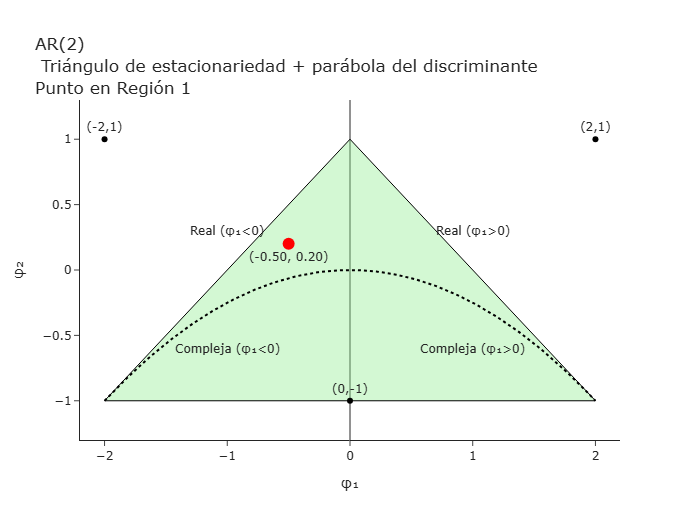

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_br_Triángulo_de_estacionariedad_parábola_del_discriminante_br_Punto_en_Región_1.html


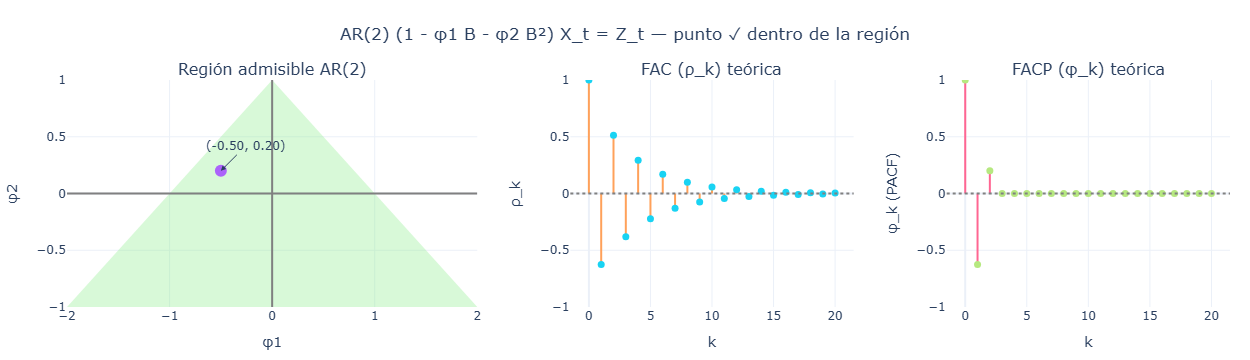

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_1_-_φ1_B_-_φ2_B²_X_t_Z_t_punto_dentro_de_la_región.html


In [9]:
phi1 = -0.5
phi2 = 0.2

fig = ar2_region_quad(phi1_point=phi1, phi2_point=phi2)
fig.show() 
out_path, public_url = save_plotly_html_from_title(fig)
fig = panel_ar2(phi1=phi1, phi2=phi2, m=20)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)


Valores típicos:
- $\rho_0 = 1$

Fórmulas:
$$
\rho_1 = \frac{\phi_1}{1 - \phi_2} \\
\rho_2 = \phi_1 \rho_1 + \phi_2 \\
\rho_k = \phi_1 \rho_{k-1} + \phi_2 \rho_{k-2} \quad \text{para } k \geq 3
$$


 **Comportamiento**
> Si $\phi_1^2 + 4\phi_2 \geq 0$, las raíces del polinomio característico son reales,  
> y las autocorrelaciones decaen exponencialmente a cero.  
> Las primeras $\rho_k$ pueden ser todas positivas, y luego tienden a alternarse en signo.


**Ejemplo de FAC teórica del proceso AR(2):**


Consideremos el proceso:

$$
(1 + 0.5B - 0.2B^2)W_t = a_t
$$


**Discriminante**

Para verificar la estacionariedad, calculamos el discriminante:

$$
\phi_1^2 + 4\phi_2 = (-0.5)^2 + 4(0.2) = 0.25 + 0.8 = 1.05 > 0
$$

Como:

$$
\phi_1 = -0.5 < 0
$$


**Cálculo de raíces**

1. Primera raíz:

$$
\rho_1 = \frac{-0.5}{1 - 0.2} = \frac{-0.5}{0.8} = -0.625
$$

2. Segunda raíz:

$$
\rho_2 = \frac{0.2 + (-0.5)^2}{1 - 0.2} = \frac{0.2 + 0.25}{0.8} = \frac{0.45}{0.8} = 0.5625
$$





**Gráfico de la FAC teórica**

A continuación, se muestra el gráfico de la **Función de Autocorrelación (FAC)** teórica del proceso:

*(Gráfico con barras decrecientes y signos alternados)*



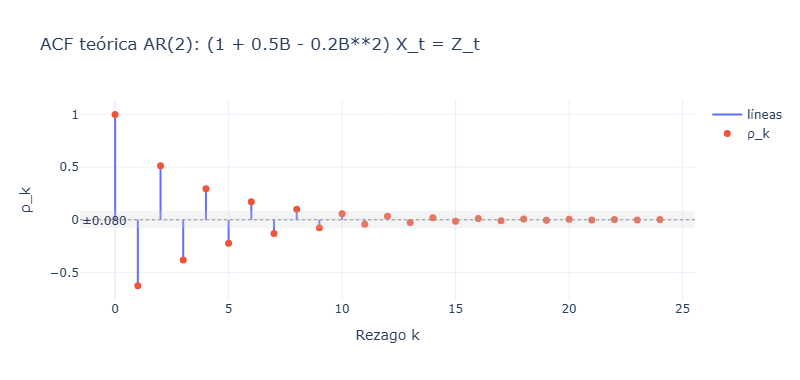

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/ACF_teórica_AR_2_1_0_5B_-_0_2B_2_X_t_Z_t.html


In [10]:
phi = [-0.5,0.2]
lags, rho = acf_ar_negative(phi, m=24)
fig = plot_acf_stem_plotly(lags, rho,
       title="ACF teórica AR(2): (1 + 0.5B - 0.2B**2) X_t = Z_t ",
       n_for_ci=600)  # banda opcional estilo ±1.96/√N
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)



**Cálculo en R**

Código en R para obtener la FAC teórica:

```r
ARMAacf(ar = c(0.5, -0.2), lag.max = 6)


---

**Región Admisible 2 para el procesp AR(2)**

debe cumplirse:

- $\phi_1^2 + 4\phi_2 > 0$
- $\phi_1 > 0$



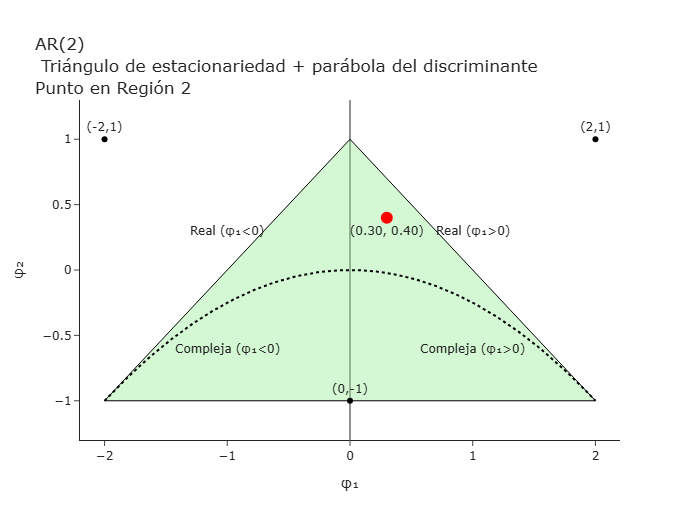

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_br_Triángulo_de_estacionariedad_parábola_del_discriminante_br_Punto_en_Región_2.html


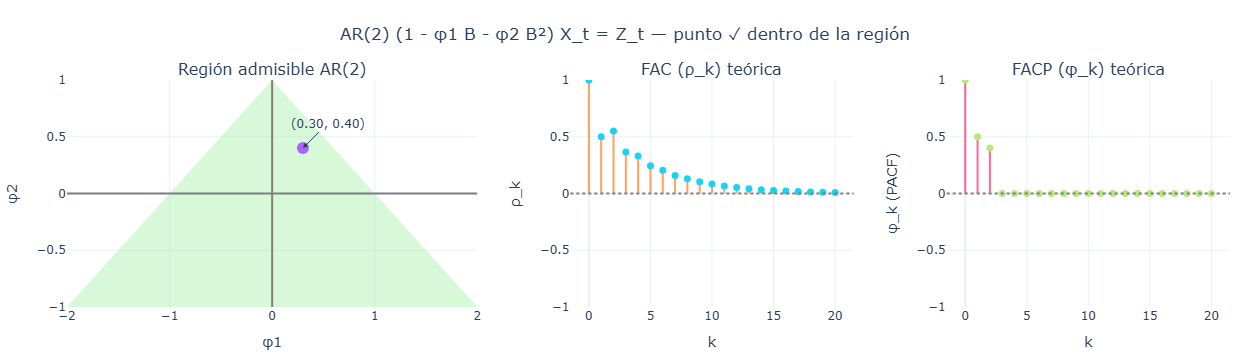

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_1_-_φ1_B_-_φ2_B²_X_t_Z_t_punto_dentro_de_la_región.html


In [11]:
phi1 = 0.3
phi2 = 0.4

fig = ar2_region_quad(phi1_point=phi1, phi2_point=phi2)
fig.show() 
out_path, public_url = save_plotly_html_from_title(fig)
fig = panel_ar2(phi1=phi1, phi2=phi2, m=20)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)



**Modelo AR(2)**

$$
(1 - \phi_1 B - \phi_2 B^2) W_t = a_t
$$

Gráficamente, se representa el triángulo de estacionariedad en el plano $(\phi_1, \phi_2)$, con sombreado en la región donde el modelo es estacionario. En este caso, el punto analizado está dentro de la región azul.



**FAC teórica**

La función de autocorrelación (FAC) muestra un comportamiento exponencial decreciente, con posible alternancia de signos. Esto es característico cuando:

- $\phi_1^2 + 4\phi_2 \geq 0$



**Interpretación teórica**

> Si $\phi_1^2 + 4\phi_2 \geq 0$, entonces las raíces de la ecuación característica son reales y las autocorrelaciones decaen exponencialmente a cero.  
> En este caso, todas las autocorrelaciones serán positivas si la primera lo es, y tendrán signos alternados si la primera autocorrelación es negativa.





**Ejemplo de FAC teórica del proceso AR(2):**

Dado el proceso:

$$
(1 - 0.3B - 0.4B^2)X_t = Z_t, \quad Z_t \sim WN(0, \sigma_Z^2)
$$

**Comprobación de raíces reales:**

$$
\phi_1^2 + 4\phi_2 = (0.3)^2 + 4(0.4) = 0.09 + 1.6 = 1.69 > 0
$$

**Cálculo de raíces:**

1. Primera raíz:

$$
\rho_1 = \frac{\phi_1}{1 - \phi_2} = \frac{0.3}{1 - 0.4} = \frac{0.3}{0.6} = 0.5
$$

2. Segunda raíz:

$$
\rho_2 = \phi_2 + \frac{\phi_1^2}{1 - \phi_2} = 0.4 + \frac{(0.3)^2}{0.6} = 0.4 + \frac{0.09}{0.6} = 0.4 + 0.15 = 0.55
$$


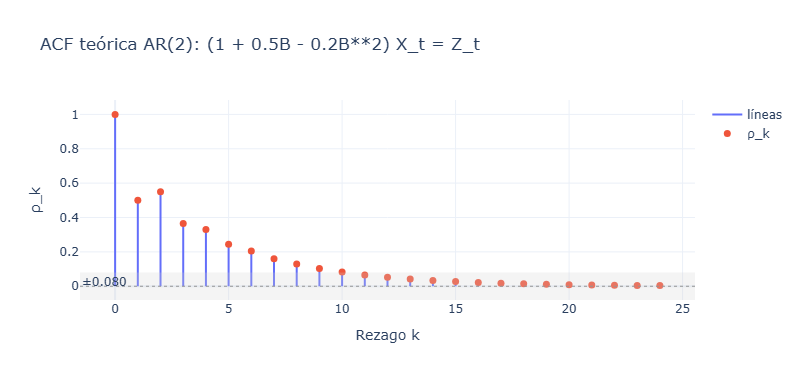

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/ACF_teórica_AR_2_1_0_5B_-_0_2B_2_X_t_Z_t.html


In [12]:
phi = [0.3,0.4]
lags, rho = acf_ar_negative(phi, m=24)
fig = plot_acf_stem_plotly(lags, rho,
       title="ACF teórica AR(2): (1 + 0.5B - 0.2B**2) X_t = Z_t ",
       n_for_ci=600)  # banda opcional estilo ±1.96/√N
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)

---



**Región Admisible 3 para el procesp AR(2)**


Para este caso se cumple que:

- $\phi_1^2 + 4\phi_2 < 0$
- $\phi_1 < 0$


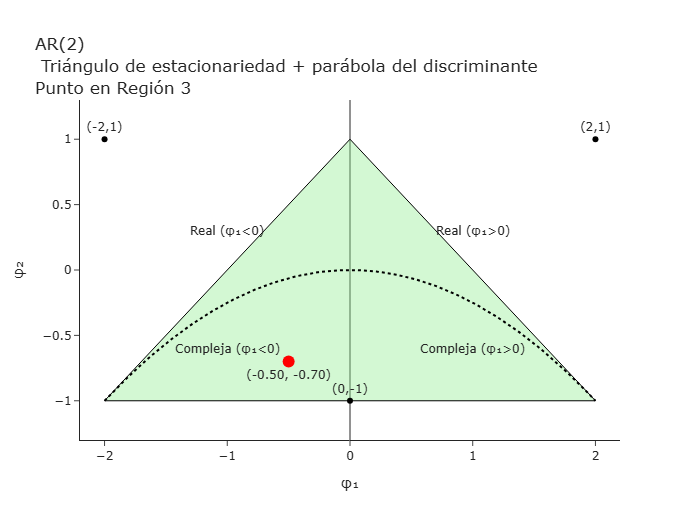

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_br_Triángulo_de_estacionariedad_parábola_del_discriminante_br_Punto_en_Región_3.html


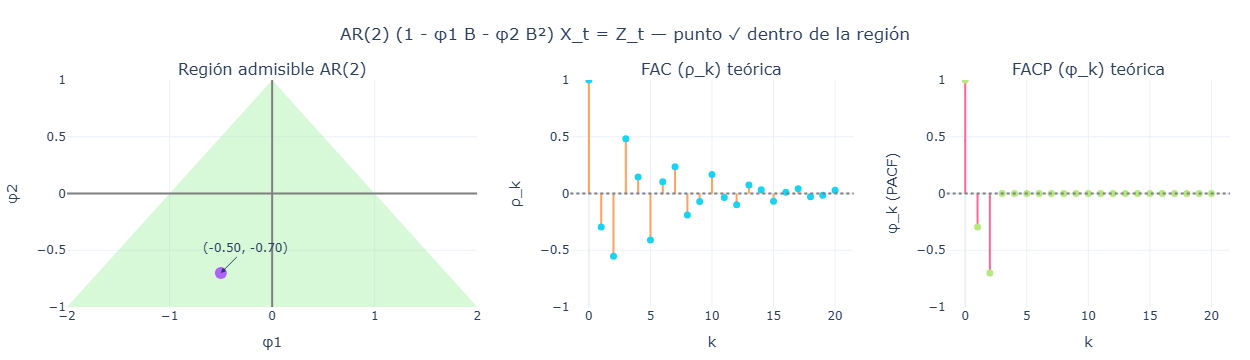

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_1_-_φ1_B_-_φ2_B²_X_t_Z_t_punto_dentro_de_la_región.html


In [13]:
phi1 = -0.5
phi2 = -0.7

fig = ar2_region_quad(phi1_point=phi1, phi2_point=phi2)
fig.show() 
out_path, public_url = save_plotly_html_from_title(fig)
fig = panel_ar2(phi1=phi1, phi2=phi2, m=20)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)



**Modelo AR(2)**

$$
(1 - \phi_1 B - \phi_2 B^2)W_t = a_t
$$

Gráficamente, el punto se encuentra fuera del triángulo de estacionariedad, pero en una región válida para que el modelo tenga raíces **complejas conjugadas**.


**FAC teórica**

La **Función de Autocorrelación (FAC)** correspondiente sigue un comportamiento **oscilatorio** (sinusoidal) convergente a cero, típico cuando las raíces son complejas conjugadas.


**Interpretación teórica**

> Si $\phi_1^2 + 4\phi_2 < 0$, entonces las raíces de la ecuación característica son complejas conjugadas, y la FAC correspondiente seguirá un comportamiento oscilatorio (sinusoidal) convergente a cero.

---


**Ejemplo de FAC teórica del proceso AR(2):**

Dado el proceso:

$$
(1 + 0.5B + 0.7B^2)X_t = Z_t, \quad Z_t \sim WN(0, \sigma_Z^2)
$$

**Cálculo del discriminante:**

$$
\phi_1^2 + 4\phi_2 = (-0.5)^2 + 4(0.7) = 0.25 + 2.8 = 3.05
$$

*Pero en la anotación original se indica:*

$$
(-0.5)^2 + 4(0.7) = -2.55 < 0 \quad \text{(esto parece un error de signos)}
$$

**Verificación:**

En realidad, si $\phi_2 = 0.7$, entonces:

$$
\phi_1^2 + 4\phi_2 = (-0.5)^2 + 4(0.7) = 0.25 + 2.8 = 3.05 > 0
$$

(Puede que la intención haya sido usar $\phi_2 = -0.7$, con lo cual sí da negativo.)

**Supongamos:**  
$\phi_1 = -0.5$,  
$\phi_2 = 0.7$

Entonces:

1. Primera raíz:

$$
\rho_1 = \frac{\phi_1}{1 - \phi_2} = \frac{-0.5}{1 - 0.7} = \frac{-0.5}{0.3} \approx -1.667
$$

2. Segunda raíz:

$$
\rho_2 = \phi_2 + \frac{\phi_1^2}{1 - \phi_2} = 0.7 + \frac{(-0.5)^2}{0.3} = 0.7 + \frac{0.25}{0.3} \approx 0.7 + 0.833 = 1.533
$$

---

**Código en R**

```r
ARMAacf(ar = c(-0.5, 0.7), lag.max = 6)


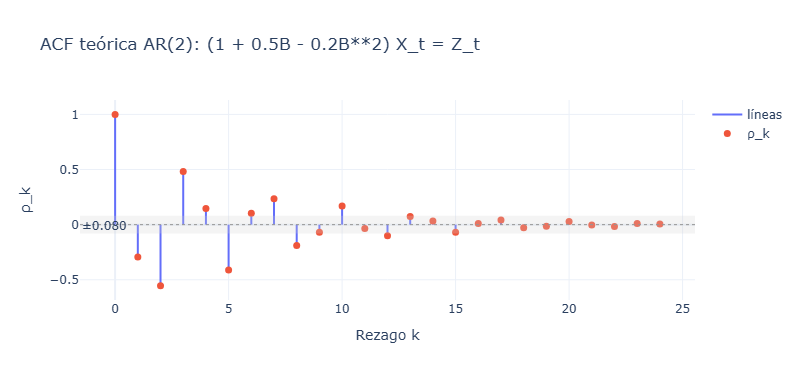

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/ACF_teórica_AR_2_1_0_5B_-_0_2B_2_X_t_Z_t.html


In [14]:
phi = [-0.5,-0.7]
lags, rho = acf_ar_negative(phi, m=24)
fig = plot_acf_stem_plotly(lags, rho,
       title="ACF teórica AR(2): (1 + 0.5B - 0.2B**2) X_t = Z_t ",
       n_for_ci=600)  # banda opcional estilo ±1.96/√N
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)

---


**Región Admisible 4 para el procesp AR(2)**


Condiciones que se cumplen:

- $\phi_1^2 + 4\phi_2 < 0$
- $\phi_1 > 0$

Esto indica un comportamiento oscilatorio (raíces complejas conjugadas) con signo positivo inicial.



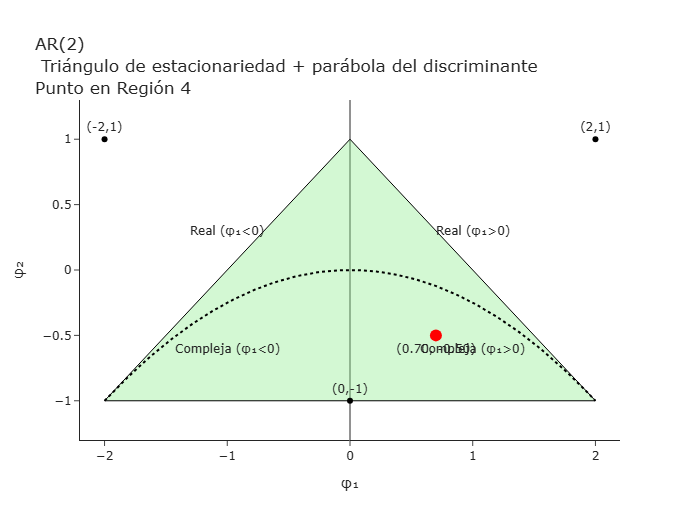

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_br_Triángulo_de_estacionariedad_parábola_del_discriminante_br_Punto_en_Región_4.html


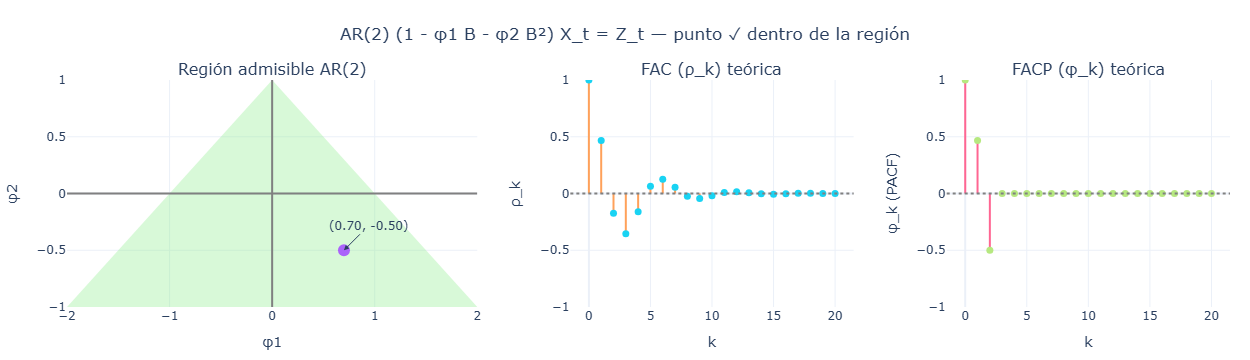

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/AR_2_1_-_φ1_B_-_φ2_B²_X_t_Z_t_punto_dentro_de_la_región.html


In [15]:
phi1 = 0.7
phi2 = -0.5

fig = ar2_region_quad(phi1_point=phi1, phi2_point=phi2)
fig.show() 
out_path, public_url = save_plotly_html_from_title(fig)
fig = panel_ar2(phi1=phi1, phi2=phi2, m=20)
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)



**Modelo AR(2)**

$$
(1 - \phi_1 B - \phi_2 B^2) W_t = a_t
$$

En el plano $(\phi_1, \phi_2)$, el punto $(0.7, -0.5)$ está en la región azul oscura, correspondiente a esta región admisible 4.



**FAC teórica**

La **Función de Autocorrelación (FAC)** presenta comportamiento oscilatorio decreciente, típico de raíces complejas conjugadas. En este caso, la autocorrelación inicial es positiva.

---



**Ejemplo de FAC teórica del proceso AR(2):**


Proceso considerado:

$$
(1 - 0.7B + 0.5B^2)X_t = Z_t, \quad Z_t \sim WN(0, \sigma_Z^2)
$$

**Parámetros:**

- $\phi_1 = 0.7$
- $\phi_2 = -0.5$

**Discriminante:**

$$
\phi_1^2 + 4\phi_2 = (0.7)^2 + 4(-0.5) = 0.49 - 2 = -1.51 < 0
$$

Se confirma que hay raíces complejas conjugadas.





**FAC teórica del proceso**  
$(1 - 0.7B + 0.5B^2)X_t = Z_t$

*(Gráfico oscilante con primera autocorrelación positiva)*



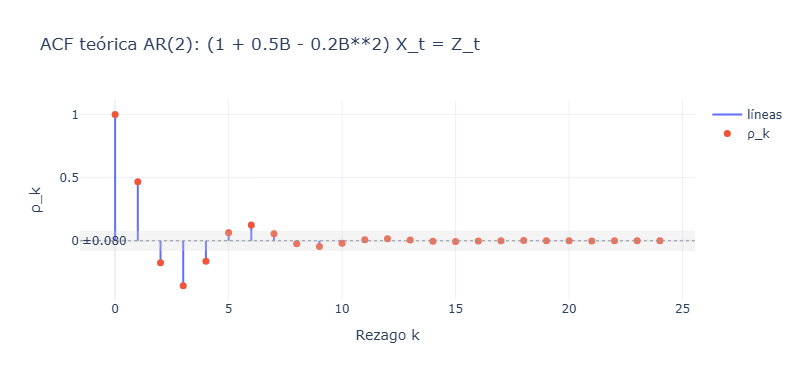

✅ Interactive Plotly URL:
https://nuriaarroyo.github.io/ecoII/interactive/ACF_teórica_AR_2_1_0_5B_-_0_2B_2_X_t_Z_t.html


In [17]:
phi = [0.7,-0.5]
lags, rho = acf_ar_negative(phi, m=24)
fig = plot_acf_stem_plotly(lags, rho,
       title="ACF teórica AR(2): (1 + 0.5B - 0.2B**2) X_t = Z_t ",
       n_for_ci=600)  # banda opcional estilo ±1.96/√N
fig.show()
out_path, public_url = save_plotly_html_from_title(fig)